# Ultrasonic Data Plots


In [25]:
import pandas as pd
import matplotlib.pyplot as plt

csv_path = r"v:\measurement_project\ultrasonic_data.csv"
df = pd.read_csv(csv_path)

# View the ultrasonic data
df.head()



,Actual,Raw,Raw+MA,Geometry,Geo+MA,Raw %Err,MA %Err,Geo %Err,GeoMA %Err
0,1.5,1.71,1.71,1.39,1.39,14.00,14.00,7.33,7.33
1,2.0,1.71,1.71,1.39,1.39,14.50,14.50,30.50,30.50
2,3.0,1.71,2.76,1.39,2.56,43.00,8.00,53.67,14.67
3,4.0,3.99,3.99,3.87,3.87,0.25,0.25,3.25,3.25
4,5.0,4.96,5.56,4.86,5.47,0.80,11.20,2.80,9.40


In [47]:
# Resolve CSV columns, but use friendly labels in plots
import re


def resolve_column(df, candidates):
    for name in candidates:
        if name in df.columns:
            return name

    normalized = {re.sub(r"[^a-z0-9]", "", c.lower()): c for c in df.columns}
    for name in candidates:
        key = re.sub(r"[^a-z0-9]", "", name.lower())
        if key in normalized:
            return normalized[key]

    raise KeyError(f"None of these columns were found: {candidates}")


actual_col = resolve_column(df, ["Actual", "Actual Distance"])

error_columns = [
    (resolve_column(df, ["Raw %Err", "Raw Error", "Raw%Err", "Raw Err"]), "Raw reading (pulse echo)"),
    (resolve_column(df, ["MA %Err", "Raw+MA %Err", "Raw MA %Err", "MA Error"]), "Raw reading (pulse echo) with moving avg"),
    (resolve_column(df, ["Geo %Err", "Geometry %Err", "Pitch Catch %Err", "Pitch-Catch %Err"]), "Pitch-catch"),
    (resolve_column(df, ["GeoMA %Err", "Geo+MA %Err", "Pitch-Catch+MA %Err", "Pitch Catch+MA %Err", "Geometry+MA %Err"]), "Pitch-catch with moving avg"),
]

series_columns = [
    (actual_col, "Actual distance"),
    (resolve_column(df, ["Raw", "Raw Distance"]), "Raw  reading (pulse echo)"),
    (resolve_column(df, ["Raw+MA", "Raw MA", "Raw_MA"]), "Raw reading (pulse echo) with moving avg"),
    (resolve_column(df, ["Geometry", "Pitch Catch", "Pitch-Catch"]), "Pitch-catch"),
    (resolve_column(df, ["Geo+MA", "GeoMA", "Pitch-Catch+MA", "Pitch Catch+MA", "Geometry+MA"]), "Pitch-catch with moving avg"),
]

Using error columns: ['Raw %Err -> Raw reading (pulse echo)', 'MA %Err -> Raw reading (pulse echo) with moving avg', 'Geo %Err -> Pitch-catch', 'GeoMA %Err -> Pitch-catch with moving avg']


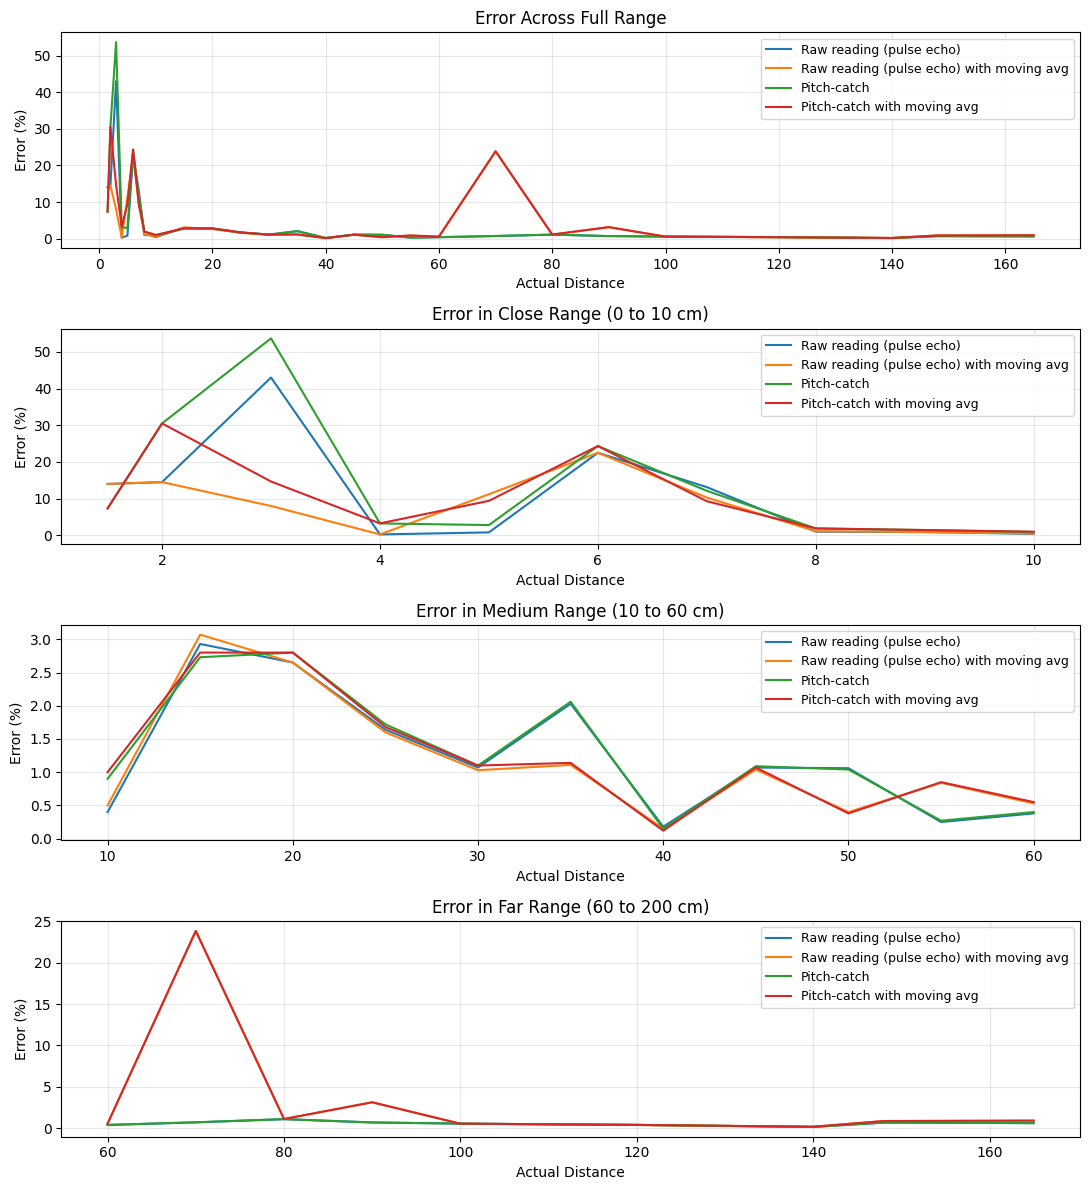

In [48]:
# Error analysis across full range and distance bands

print("Using error columns:", [f"{csv_name} -> {label}" for csv_name, label in error_columns])

fig, axes = plt.subplots(4, 1, figsize=(11, 12), sharex=False)
axes = axes.ravel()  # flatten 2x2 array into 4 axes

ranges = [
    (0, 200, "Error Across Full Range"),
    (0, 10, "Error in Close Range (0 to 10 cm)"),
    (10, 60, "Error in Medium Range (10 to 60 cm)"),
    (60, 200, "Error in Far Range (60 to 200 cm)"),
]

for ax, (start, end, title) in zip(axes, ranges):
    subset = df[(df[actual_col] >= start) & (df[actual_col] <= end)]
    for csv_name, label in error_columns:
        ax.plot(subset[actual_col], subset[csv_name], marker="", linewidth=1.5, label=label)
    ax.set_title(title)
    ax.set_xlabel("Actual Distance")
    ax.set_ylabel("Error (%)")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

Using series columns: ['Actual -> Actual distance', 'Raw -> Raw  reading (pulse echo)', 'Raw+MA -> Raw reading (pulse echo) with moving avg', 'Geometry -> Pitch-catch', 'Geo+MA -> Pitch-catch with moving avg']


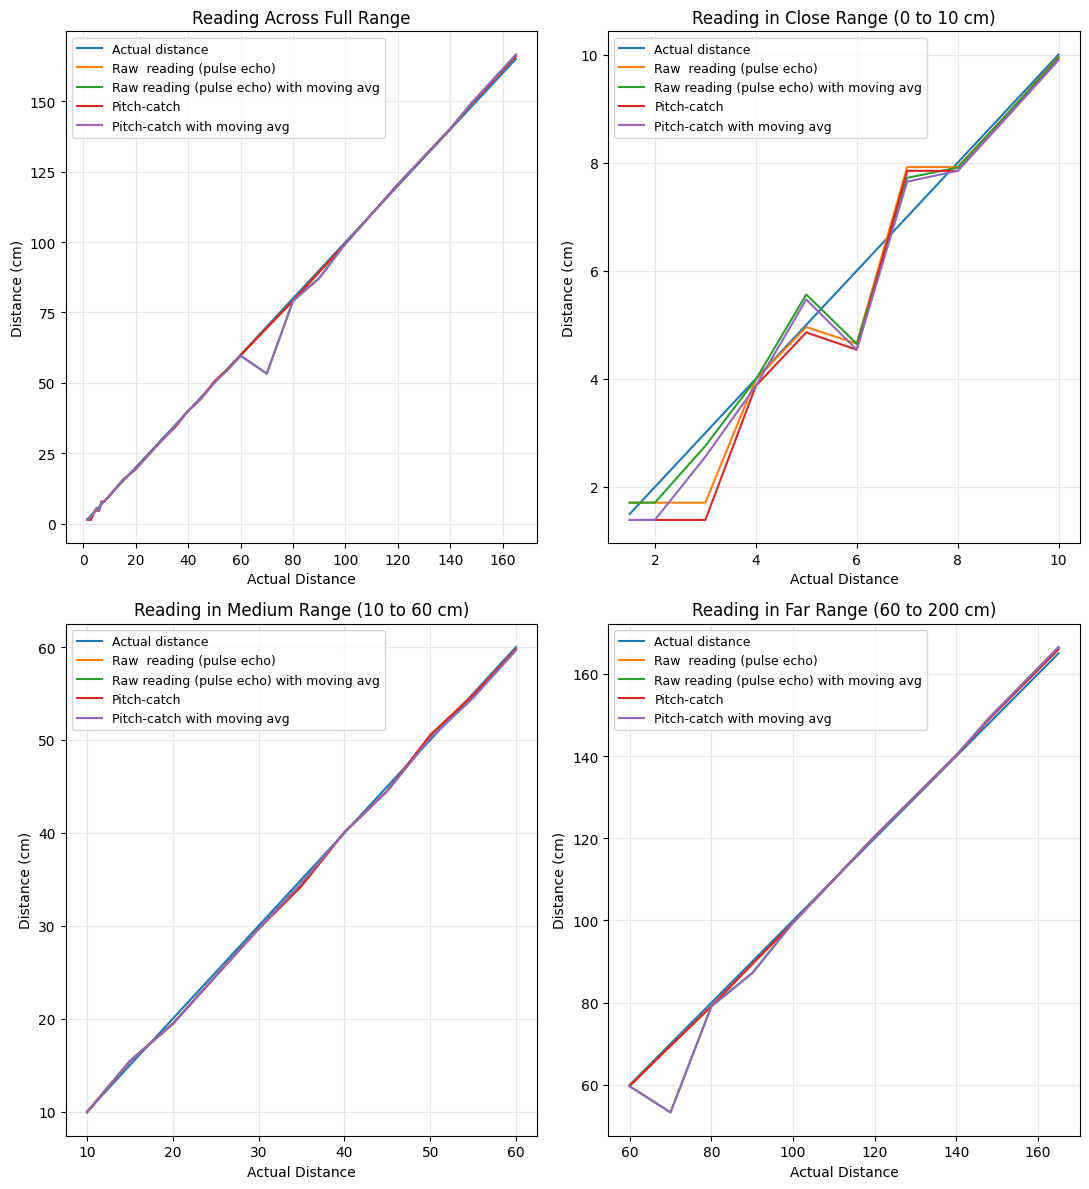

In [49]:
# Error analysis across full range and distance bands (with points)
print("Using series columns:", [f"{csv_name} -> {label}" for csv_name, label in series_columns])

fig, axes = plt.subplots(2, 2, figsize=(11, 12), sharex=False)
axes = axes.ravel()  # flatten 2x2 array into 4 axes

ranges = [
    (0, 200, "Reading Across Full Range"),
    (0, 10, "Reading in Close Range (0 to 10 cm)"),
    (10, 60, "Reading in Medium Range (10 to 60 cm)"),
    (60, 200, "Reading in Far Range (60 to 200 cm)"),
]

for ax, (start, end, title) in zip(axes, ranges):
    subset = df[(df[actual_col] >= start) & (df[actual_col] <= end)]
    for csv_name, label in series_columns:
        ax.plot(subset[actual_col], subset[csv_name], marker="", linewidth=1.5, label=label)
    ax.set_title(title)
    ax.set_xlabel("Actual Distance")
    ax.set_ylabel("Distance (cm)")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()





Using series columns: ['Actual -> Actual distance', 'Raw -> Raw  reading (pulse echo)', 'Raw+MA -> Raw reading (pulse echo) with moving avg', 'Geometry -> Pitch-catch', 'Geo+MA -> Pitch-catch with moving avg']


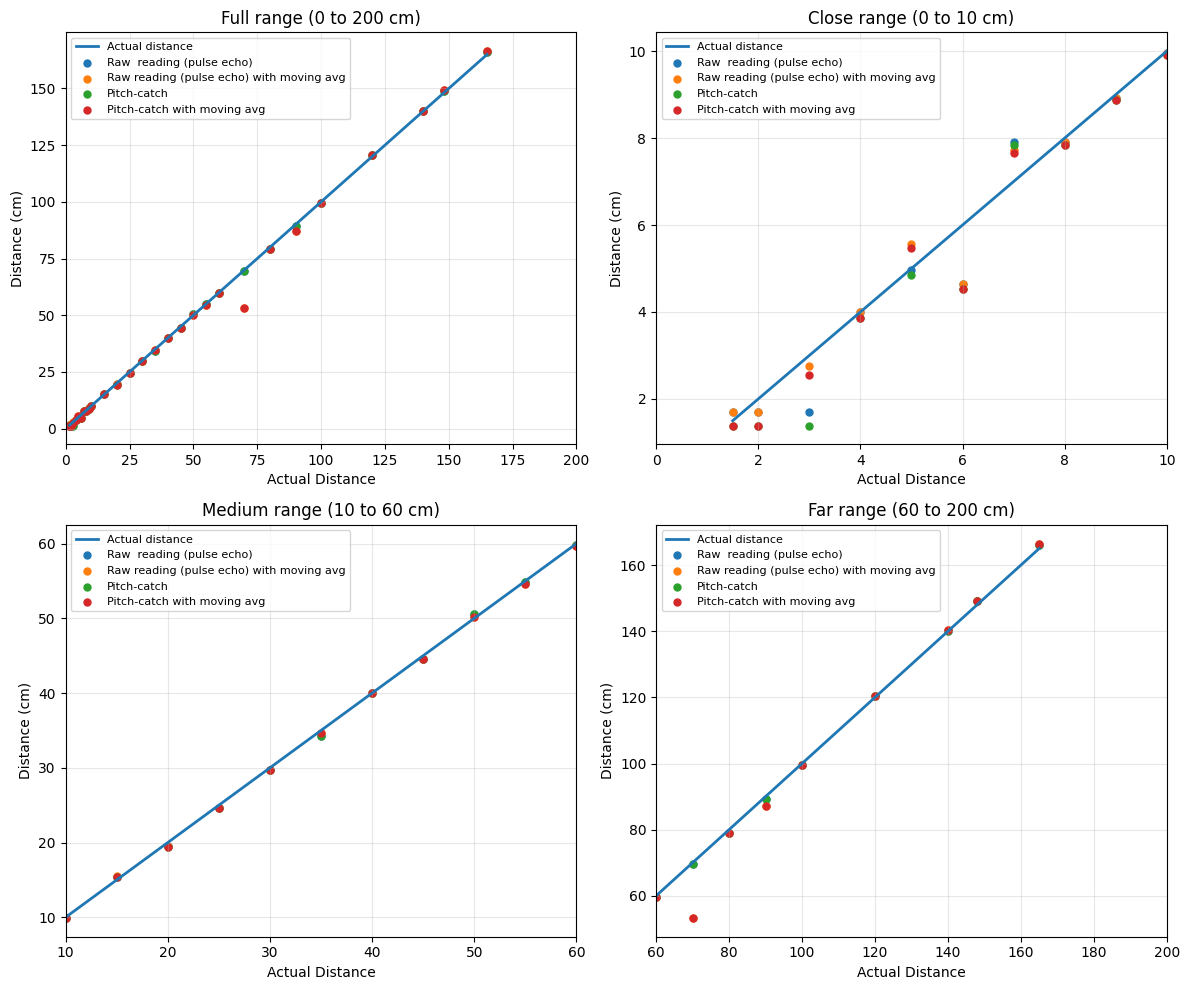

In [50]:
# Actual as line, other readings as dots, shown across full and sub-ranges
print("Using series columns:", [f"{csv_name} -> {label}" for csv_name, label in series_columns])

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=False, sharey=False)
axes = axes.ravel()

ranges = [
    (0, 200, "Full range (0 to 200 cm)"),
    (0, 10, "Close range (0 to 10 cm)"),
    (10, 60, "Medium range (10 to 60 cm)"),
    (60, 200, "Far range (60 to 200 cm)"),
]

for ax, (start, end, title) in zip(axes, ranges):
    subset = df[(df[actual_col] >= start) & (df[actual_col] <= end)]

    for csv_name, label in series_columns:
        if csv_name == actual_col:
            ax.plot(subset[actual_col], subset[csv_name], linewidth=2.0, label=label)
        else:
            ax.scatter(subset[actual_col], subset[csv_name], s=25, label=label)

    ax.set_xlim(start, end)
    ax.set_title(title)
    ax.set_xlabel("Actual Distance")
    ax.set_ylabel("Distance (cm)")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

Accuracy metrics by range (sorted by MAE):


,Range,Method,N,MAE,RMSE,MAPE (%),Bias
0,All (0-200),Raw reading (pulse echo),28,0.478214,0.605737,4.592760,-0.131071
2,All (0-200),Pitch-catch,28,0.514286,0.647561,5.588037,-0.192143
1,All (0-200),Raw reading (pulse echo) with moving avg,28,1.128571,3.251603,4.521947,-0.722143
3,All (0-200),Pitch-catch with moving avg,28,1.154643,3.256974,5.234315,-0.778929
5,Close (0-10),Raw reading (pulse echo) with moving avg,10,0.360000,0.534547,8.324960,-0.062000
7,Close (0-10),Pitch-catch with moving avg,10,0.425000,0.584731,10.308849,-0.201000
4,Close (0-10),Raw reading (pulse echo),10,0.431000,0.669126,11.048175,-0.205000
6,Close (0-10),Pitch-catch,10,0.528000,0.769051,13.824563,-0.358000
12,Far (60-200),Raw reading (pulse echo),9,0.605556,0.667624,0.582307,-0.007778
14,Far (60-200),Pitch-catch,9,0.605556,0.666375,0.584147,-0.012222



Best method in each range (by minimum MAE):


,Range,Method,MAE,RMSE,MAPE (%),Bias
0,All (0-200),Raw reading (pulse echo),0.478214,0.605737,4.592760,-0.131071
5,Close (0-10),Raw reading (pulse echo) with moving avg,0.360000,0.534547,8.324960,-0.062000
12,Far (60-200),Raw reading (pulse echo),0.605556,0.667624,0.582307,-0.007778
9,Medium (10-60),Raw reading (pulse echo) with moving avg,0.331818,0.367015,1.175312,-0.200909


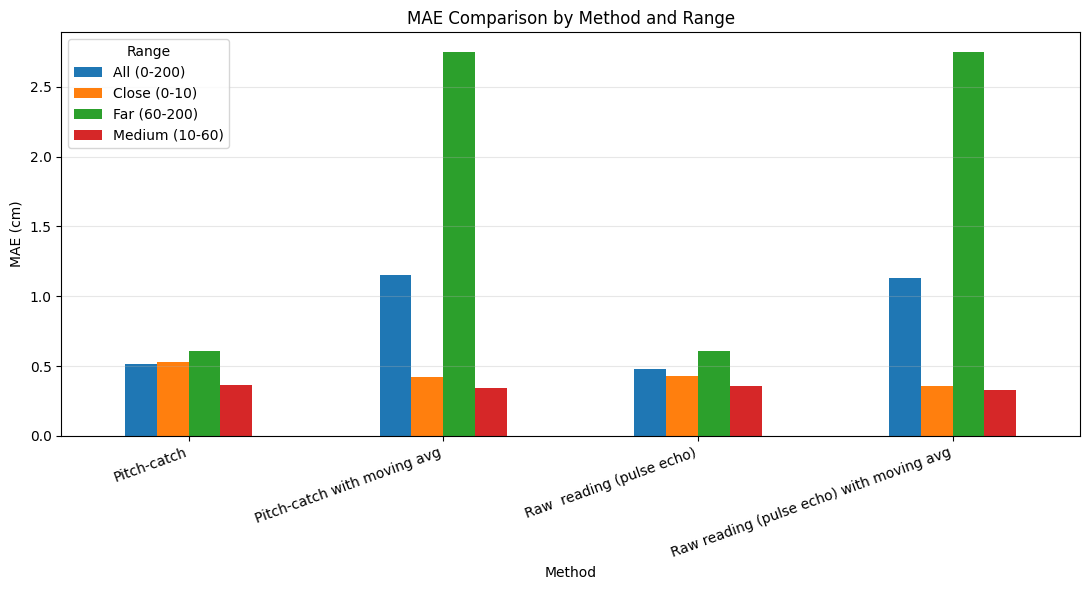

In [51]:
# Accuracy comparison across full range and distance bands
# Metrics used: MAE, RMSE, MAPE, and bias (lower absolute values are better)

comparison_ranges = [
    (0, 200, "All (0-200)"),
    (0, 10, "Close (0-10)"),
    (10, 60, "Medium (10-60)"),
    (60, 200, "Far (60-200)"),
]

methods = [(csv_name, label) for csv_name, label in series_columns if csv_name != actual_col]

rows = []
for start, end, range_label in comparison_ranges:
    subset = df[(df[actual_col] >= start) & (df[actual_col] <= end)].copy()
    n = len(subset)
    if n == 0:
        continue

    actual = subset[actual_col]
    for csv_name, label in methods:
        err = subset[csv_name] - actual
        abs_err = err.abs()
        sq_err = err ** 2
        ape = (abs_err / actual.replace(0, pd.NA)) * 100

        rows.append({
            "Range": range_label,
            "Method": label,
            "N": n,
            "MAE": abs_err.mean(),
            "RMSE": (sq_err.mean()) ** 0.5,
            "MAPE (%)": ape.mean(skipna=True),
            "Bias": err.mean(),
        })

metrics_df = pd.DataFrame(rows)
metrics_df = metrics_df.sort_values(["Range", "MAE"], ascending=[True, True])

print("Accuracy metrics by range (sorted by MAE):")
display(metrics_df)

best_by_range = metrics_df.loc[metrics_df.groupby("Range")["MAE"].idxmin(), ["Range", "Method", "MAE", "RMSE", "MAPE (%)", "Bias"]]
best_by_range = best_by_range.sort_values("Range")

print("\nBest method in each range (by minimum MAE):")
display(best_by_range)

# Visual check: MAE by method for each range
pivot_mae = metrics_df.pivot(index="Method", columns="Range", values="MAE")
ax = pivot_mae.plot(kind="bar", figsize=(11, 6))
ax.set_title("MAE Comparison by Method and Range")
ax.set_ylabel("MAE (cm)")
ax.grid(True, axis="y", alpha=0.3)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

MAE before vs after extreme outlier removal (by range):


C:\Users\getso\AppData\Local\Temp\ipykernel_27020\1347598821.py:47: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(remove_extreme_iqr)
C:\Users\getso\AppData\Local\Temp\ipykernel_27020\1347598821.py:47: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(remove_extreme_iqr)
C:\Users\getso\AppData\Local\Temp\ipykernel_27020\1347598821.py:47: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns

,Range,Method,MAE (Before),MAE (After Outlier Removal),N Before,N After,Removed Points
3,All (0-200),Raw reading (pulse echo) with moving avg,1.128571,0.465000,28,26,2
2,All (0-200),Raw reading (pulse echo),0.478214,0.478214,28,28,0
1,All (0-200),Pitch-catch with moving avg,1.154643,0.492692,28,26,2
0,All (0-200),Pitch-catch,0.514286,0.514286,28,28,0
7,Close (0-10),Raw reading (pulse echo) with moving avg,0.360000,0.360000,10,10,0
5,Close (0-10),Pitch-catch with moving avg,0.425000,0.425000,10,10,0
6,Close (0-10),Raw reading (pulse echo),0.431000,0.431000,10,10,0
4,Close (0-10),Pitch-catch,0.528000,0.528000,10,10,0
14,Far (60-200),Raw reading (pulse echo),0.605556,0.605556,9,9,0
12,Far (60-200),Pitch-catch,0.605556,0.605556,9,9,0



Decision (best method in each range):


,Range,Method,MAE (After Outlier Removal),MAE (Before),Removed Points
3,All (0-200),Raw reading (pulse echo) with moving avg,0.465000,1.128571,2
7,Close (0-10),Raw reading (pulse echo) with moving avg,0.360000,0.360000,0
14,Far (60-200),Raw reading (pulse echo),0.605556,0.605556,0
11,Medium (10-60),Raw reading (pulse echo) with moving avg,0.331818,0.331818,0


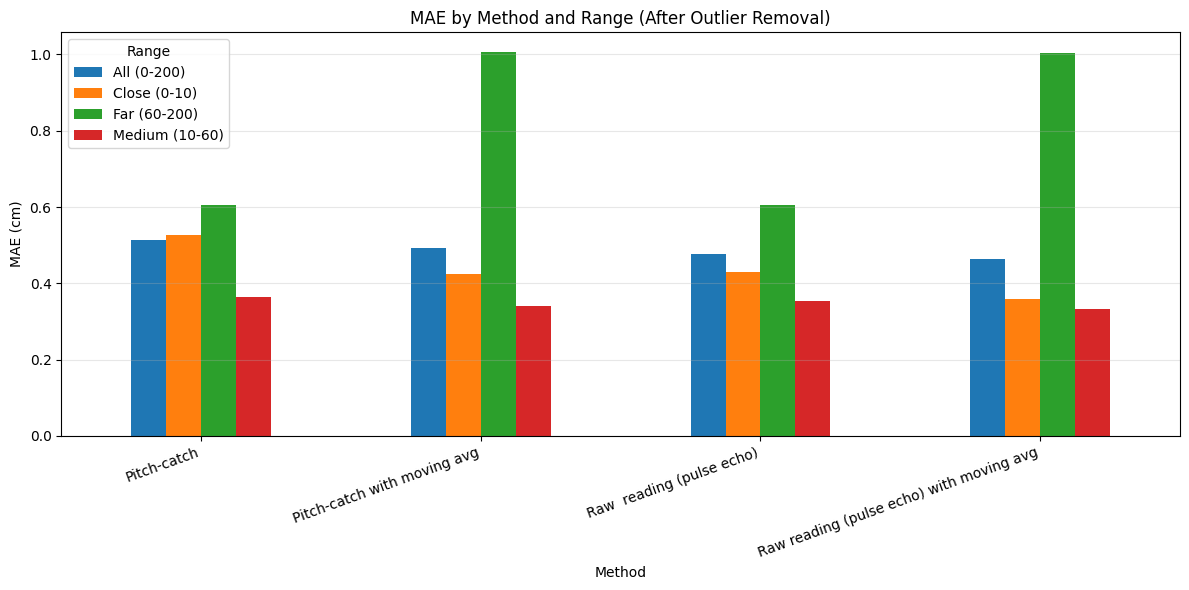

In [52]:
# Outlier-robust MAE comparison by range (all + segments)
# Removes extreme outliers in absolute error per method within each range,
# then compares MAE and gives a decision (best method) per range.

methods = [(csv_name, label) for csv_name, label in series_columns if csv_name != actual_col]

comparison_ranges = [
    (0, 200, "All (0-200)"),
    (0, 10, "Close (0-10)"),
    (10, 60, "Medium (10-60)"),
    (60, 200, "Far (60-200)"),
]


def remove_extreme_iqr(group):
    q1 = group["AbsError"].quantile(0.25)
    q3 = group["AbsError"].quantile(0.75)
    iqr = q3 - q1
    low = q1 - 3.0 * iqr
    high = q3 + 3.0 * iqr
    if iqr == 0:
        return group.copy()
    return group[(group["AbsError"] >= low) & (group["AbsError"] <= high)]


all_results = []

for start, end, range_label in comparison_ranges:
    subset = df[(df[actual_col] >= start) & (df[actual_col] <= end)].copy()

    records = []
    for csv_name, label in methods:
        err = (subset[csv_name] - subset[actual_col]).abs()
        for value in err.dropna():
            records.append({
                "Range": range_label,
                "Method": label,
                "AbsError": float(value),
            })

    err_df = pd.DataFrame(records)
    if err_df.empty:
        continue

    filtered_df = (
        err_df.groupby("Method", group_keys=False)
        .apply(remove_extreme_iqr)
        .reset_index(drop=True)
    )

    mae_before = (
        err_df.groupby(["Range", "Method"], as_index=False)["AbsError"]
        .mean()
        .rename(columns={"AbsError": "MAE (Before)"})
    )

    mae_after = (
        filtered_df.groupby(["Range", "Method"], as_index=False)["AbsError"]
        .mean()
        .rename(columns={"AbsError": "MAE (After Outlier Removal)"})
    )

    counts_before = err_df.groupby(["Range", "Method"]).size().rename("N Before")
    counts_after = filtered_df.groupby(["Range", "Method"]).size().rename("N After")

    mae_compare = mae_before.merge(mae_after, on=["Range", "Method"], how="left")
    mae_compare = mae_compare.merge(counts_before.reset_index(), on=["Range", "Method"], how="left")
    mae_compare = mae_compare.merge(counts_after.reset_index(), on=["Range", "Method"], how="left")
    mae_compare["N After"] = mae_compare["N After"].fillna(0).astype(int)
    mae_compare["Removed Points"] = mae_compare["N Before"] - mae_compare["N After"]

    all_results.append(mae_compare)


range_mae_df = pd.concat(all_results, ignore_index=True)
range_mae_df = range_mae_df.sort_values(["Range", "MAE (After Outlier Removal)"])

print("MAE before vs after extreme outlier removal (by range):")
display(range_mae_df)

# Decision: best method in each range (minimum MAE after outlier removal)
decision_df = range_mae_df.loc[
    range_mae_df.groupby("Range")["MAE (After Outlier Removal)"].idxmin(),
    ["Range", "Method", "MAE (After Outlier Removal)", "MAE (Before)", "Removed Points"],
].sort_values("Range")

print("\nDecision (best method in each range):")
display(decision_df)

# Visual comparison of MAE after outlier removal across ranges
plot_df = range_mae_df.pivot(index="Method", columns="Range", values="MAE (After Outlier Removal)")
ax = plot_df.plot(kind="bar", figsize=(12, 6))
ax.set_title("MAE by Method and Range (After Outlier Removal)")
ax.set_ylabel("MAE (cm)")
ax.grid(True, axis="y", alpha=0.3)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

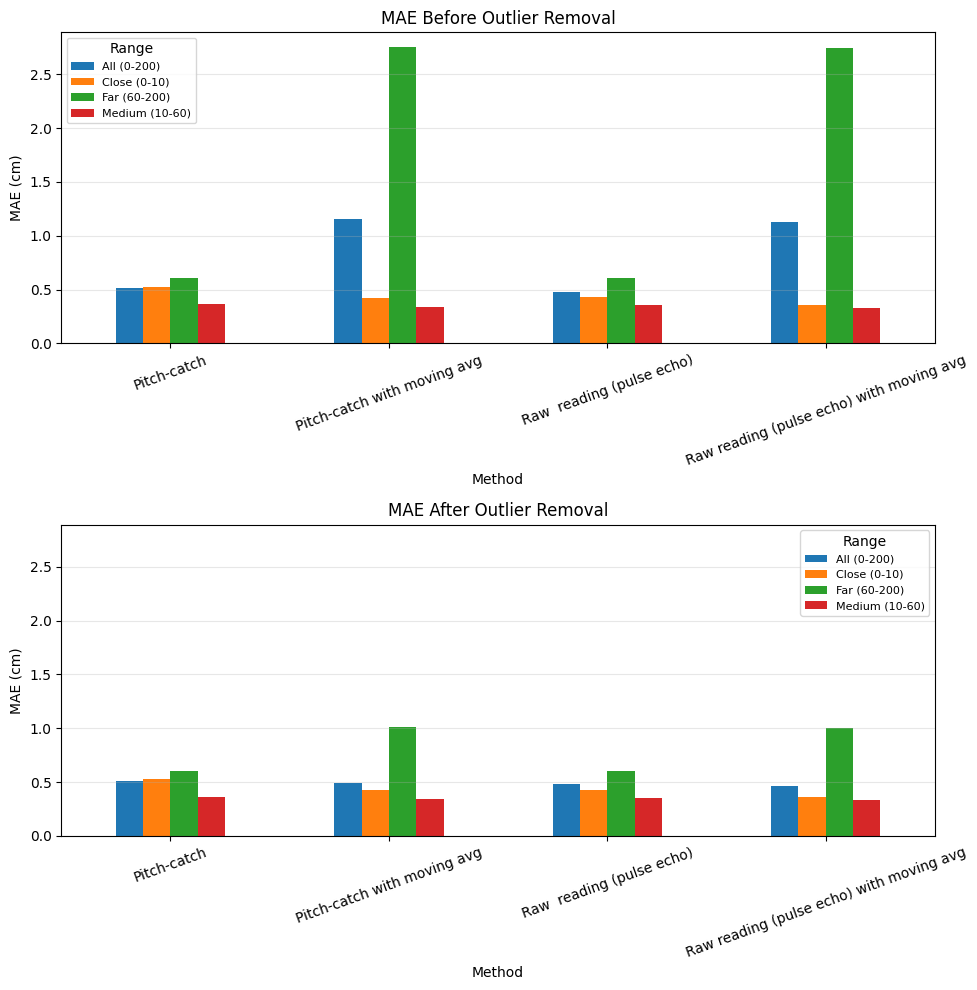

In [57]:
# Two-subplot MAE bars: before vs after outlier removal
# Requires `range_mae_df` from the range-based outlier analysis cell.

if "range_mae_df" not in globals() or range_mae_df.empty:
    raise ValueError("Run the range-based outlier analysis cell first to create `range_mae_df`.")

before_df = range_mae_df.pivot(index="Method", columns="Range", values="MAE (Before)")
after_df = range_mae_df.pivot(index="Method", columns="Range", values="MAE (After Outlier Removal)")

fig, axes = plt.subplots(2, 1, figsize=(10, 10), sharey=True)

before_df.plot(kind="bar", ax=axes[0])
axes[0].set_title("MAE Before Outlier Removal")
axes[0].set_ylabel("MAE (cm)")
axes[0].grid(True, axis="y", alpha=0.3)
axes[0].tick_params(axis="x", rotation=20)

after_df.plot(kind="bar", ax=axes[1])
axes[1].set_title("MAE After Outlier Removal")
axes[1].set_ylabel("MAE (cm)")
axes[1].grid(True, axis="y", alpha=0.3)
axes[1].tick_params(axis="x", rotation=20)

for ax in axes:
    ax.legend(title="Range", fontsize=8)

plt.tight_layout()
plt.show()